<a href="https://colab.research.google.com/github/Shahad-Hossain/nasa-image-enhancement/blob/main/Homework_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image
from PIL import ImageFilter
import math
from collections import defaultdict
import random
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [ ]:
input1 = "image_7.jpg"
try:
    img1 = Image.open(input1).convert('L') # Convert to RGB to ensure consistent 3-channel access
except FileNotFoundError:
    print(f"Error: The file '{input1}' was not found.")
    exit()

pixels1 = img1.load()

width1, height1 = img1.size

print(str(width1) + " " + str(height1))

img1.save("grayscaled.jpg")

800 583


In [ ]:
def getMinNeighbor(imgPixels, width, height, x, y, size):
  minNeighbor = 256
  for i in range(max(x - (size//2), 0), min(width, x + ((size - 1)//2))):
    for j in range(max(y - (size//2), 0), min(height, y + ((size - 1)//2))):
      minNeighbor = imgPixels[i, j] if imgPixels[i, j] < minNeighbor else minNeighbor

  return minNeighbor

def getMaxNeighbor(imgPixels, width, height, x, y, size):
  maxNeighbor = -1
  for i in range(max(x - (size//2), 0), min(width, x + ((size - 1)//2))):
    for j in range(max(y - (size//2), 0), min(height, y + ((size - 1)//2))):
      maxNeighbor = imgPixels[i, j] if imgPixels[i, j] > maxNeighbor else maxNeighbor

  return maxNeighbor

def binDilation(img, boxSize):
  width, height = img.size

  newImg = Image.new("L", size=(width, height))
  pixels = img.load()
  newPixels = newImg.load()

  for i in range(width):
    if (i % 100 == 0):
      print("On Col " + str(i) + "/" + str(width))
    for j in range(height):
      maxNeighbor = getMaxNeighbor(pixels, width, height, i, j, boxSize)

      newPixels[i, j] = maxNeighbor

  return newImg

def binErosion(img, boxSize):
  width, height = img.size

  newImg = Image.new("1", size=(width, height))
  pixels = img.load()
  newPixels = newImg.load()

  for i in range(width):
    if (i % 100 == 0):
      print("On Col " + str(i) + "/" + str(width))
    for j in range(height):
      minNeighbor = getMinNeighbor(pixels, width, height, i, j, boxSize)

      newPixels[i, j] = minNeighbor

  return newImg

def binDilation(img, boxSize):
  width, height = img.size

  newImg = Image.new("1", size=(width, height))
  pixels = img.load()
  newPixels = newImg.load()

  for i in range(width):
    if (i % 100 == 0):
      print("On Col " + str(i) + "/" + str(width))
    for j in range(height):
      maxNeighbor = getMaxNeighbor(pixels, width, height, i, j, boxSize)

      newPixels[i, j] = maxNeighbor

  return newImg
def binInvert(img):
  width, height = img.size
  newImg = Image.new("1", size=(width, height))
  pixels = img.load()
  newPixels = newImg.load()
  for i in range(width):
    for j in range(height):
      newPixels[i, j] = 1 - pixels[i, j]
  return newImg

def showHistogramBar(img, midpoint=None, threshold=None, lowerMean=None, upperMean=None):
    width, height = img.size
    pixels = img.load()

    # Build histogram
    hist = [0] * 256
    for i in range(width):
        for j in range(height):
            hist[pixels[i, j]] += 1

    # Plot as bar graph
    plt.figure(figsize=(10, 5))
    plt.bar(range(256), hist, width=1.0)

    # Optional markers
    if midpoint is not None:
        plt.axvline(midpoint, color='orange', linestyle='--', label=f"Midpoint ({midpoint})")

    if lowerMean is not None:
      plt.axvline(lowerMean, color='green', linestyle='--', label=f"Lower Mean ({lowerMean})")

    if upperMean is not None:
      plt.axvline(upperMean, color='green', linestyle='--', label=f"Upper Mean ({upperMean})")

    if threshold is not None:
        plt.axvline(threshold, color='red', linestyle='--', label=f"Threshold ({threshold})")

    plt.title("Grayscale Histogram (Bar Graph)")
    plt.xlabel("Pixel Intensity (0–255)")
    plt.ylabel("Frequency")
    plt.xlim([0, 255])

    if midpoint is not None or threshold is not None:
        plt.legend()

    plt.grid(True, axis='y')
    plt.show()

def getNeighbors(imgPixels, width, height, x, y, size):
  neighbors = []
  for i in range(max(x - (size//2), 0), min(width, x + ((size - 1)//2))):
    for j in range(max(y - (size//2), 0), min(height, y + ((size - 1)//2))):
      neighbors.append(imgPixels[i, j])

  return neighbors

def getMeanVar(neighbors):

  mean = 0
  var = 0
  for val in neighbors:
    mean += val
    var += math.pow(val, 2)

  mean /= len(neighbors)
  var /= len(neighbors)
  var -= math.pow(mean, 2)

  return mean, var







  #Thresholding calculations


def binAdd(img_1, img_2):
  width, height = img_1.size
  pixels_1 = img_1.load()
  pixels_2 = img_2.load()

  newImg = Image.new("1", size=(width, height))
  newPixels = newImg.load()
  for i in range(width):
    for j in range(height):
      newPixels[i, j] = min(pixels_1[i, j] + pixels_2[i, j], 1)

  return newImg

def varianceMask(img, threshold, boxSize):
  width, height = img.size
  pixels = img.load()

  newImg = Image.new("1", size=(width, height))
  newPixels = newImg.load()
  for i in range(width):
    for j in range(height):
      pixel = pixels[i, j]

      mean, var = getMeanVar(getNeighbors(pixels, width, height, i, j, boxSize))

      std = math.sqrt(var)

      if (var >= threshold):
        newPixels[i, j] = 1
      else:
        newPixels[i, j] = 0

  return newImg

def stdMask(img, threshold, boxSize):
  width, height = img.size
  pixels = img.load()

  newImg = Image.new("1", size=(width, height))
  newPixels = newImg.load()
  for i in range(width):
    for j in range(height):
      pixel = pixels[i, j]

      mean, var = getMeanVar(getNeighbors(pixels, width, height, i, j, boxSize))

      std = math.sqrt(var)

      if (std >= threshold):
        newPixels[i, j] = 1
      else:
        newPixels[i, j] = 0

  return newImg

def globalVarianceThresholding(img, boxSize):
  width, height = img.size
  pixels = img.load()

  averageVariance = 0

  newImg = Image.new("1", size=(width, height))
  newPixels = newImg.load()

  for i in range(width):
    for j in range(height):
      mean, var = getMeanVar(getNeighbors(pixels, width, height, i, j, boxSize))

      averageVariance += var

  averageVariance /= (width * height)

  for i in range(width):
    for j in range(height):
      mean, var = getMeanVar(getNeighbors(pixels, width, height, i, j, boxSize))

      if (var >= averageVariance):
        newPixels[i, j] = 1
      else:
        newPixels[i, j] = 0

  return newImg
#HOMEWORK 7 FUNCTIONS




def greyToBin(img, threshold):
  width, height = img.size

  newImg = Image.new("1", size=(width, height))
  pixels = img.load()
  newPixels = newImg.load()
  for i in range(width):
    for j in range(height):
      pixelVal = pixels[i, j]

      if (pixelVal >= threshold):
        newPixels[i, j] = 1
      else:
        newPixels[i, j] = 0

  return newImg



k = 0.2
R = 128
def calculateSauvola(imgPixels, width, height, x, y, size):
  mean, var = getMeanVar(getNeighbors(imgPixels, width, height, x, y, size))
  return mean * (1 + k * ((var / R) - 1))

def greyToSauvolaBin(img, neighborhoodSize):
  width, height = img.size

  newImg = Image.new("1", size=(width, height))
  pixels = img.load()
  newPixels = newImg.load()
  for i in range(width):
    for j in range(height):
      pixelVal = pixels[i, j]

      threshold = calculateSauvola(pixels, width, height, i, j, neighborhoodSize)
      if (pixelVal >= threshold):
        newPixels[i, j] = 1
      else:
        newPixels[i, j] = 0

  return newImg


def globalThreshold(img):
  width, height = img.size
  pixels = img.load()

  histogram = defaultdict(int)
  for i in range(width):
    for j in range(height):
      histogram[pixels[i, j]] += 1

  target = (width * height) * (45 / 100.0)

  cumulative = 0
  selectedPixel = 0
  for i in range(256):
    cumulative += histogram[i]
    if cumulative >= target:
      selectedPixel = i
      break

  return greyToBin(img, selectedPixel)

def threeLevelGlobalThresholding(img, thresh1, thresh2):
  width, height = img.size

  newImg = Image.new("1", size=(width, height))
  pixels = img.load()
  newPixels = newImg.load()
  for i in range(width):
    for j in range(height):
      pixelVal = pixels[i, j]

      if (pixelVal >= thresh2):
        newPixels[i, j] = 1
      elif (pixelVal >= thresh1):
        newPixels[i, j] = 0
      else:
        newPixels[i, j] = 1

  return newImg






def varianceMask(img, threshold, boxSize):
  width, height = img.size
  pixels = img.load()

  newImg = Image.new("1", size=(width, height))
  newPixels = newImg.load()
  for i in range(width):
    for j in range(height):
      pixel = pixels[i, j]

      mean, var = getMeanVar(getNeighbors(pixels, width, height, i, j, boxSize))

      std = math.sqrt(var)

      if (var >= threshold):
        newPixels[i, j] = 1
      else:
        newPixels[i, j] = 0

  return newImg







def basicGlobalThresholding(img, initialT=None):
  width, height = img.size
  pixels = img.load()

  hist = defaultdict(int)
  threshold = 0
  for i in range(width):
    for j in range(height):
      hist[pixels[i, j]] += 1

  mean = 0
  for i in range(256):
    mean += hist[i] * i

  mean /= (width * height)
  if initialT is not None:
    prevMean = initialT
  else:
    prevMean = mean
  print(prevMean)
  while True:
    subMean = 0
    subCount = 0
    upMean = 0
    upCount = 0

    for i in range(int(prevMean)):
      subMean += hist[i] * i
      subCount += hist[i]
    subMean /= subCount
    for i in range(int(prevMean), 256):
      upMean += hist[i] * i
      upCount += hist[i]
    upMean /= upCount
    print(str(subMean) + " " + str(upMean))
    newMean = (subMean + upMean) / 2
    print(newMean)
    if (newMean == prevMean):
      threshold = newMean
      break
    prevMean = newMean

  return greyToBin(img, threshold)


def adaptiveThresholding(img, boxSize):
  width, height = img.size
  pixels = img.load()

  newImg = Image.new("1", size=(width, height))
  newPixels = newImg.load()

  for i in range(0, width, boxSize):
    for j in range(0, height, boxSize):
      boxArray = []

      for k in range(i, min(i + boxSize, width)):
        for l in range(j, min(j + boxSize, height)):
          boxArray.append(pixels[k, l])
      mean, var = getMeanVar(boxArray)

      for k in range(i, min(i + boxSize, width)):
        for l in range(j, min(j + boxSize, height)):
          if (pixels[k, l] >= mean):
            newPixels[k, l] = 1
          else:
            newPixels[k, l] = 0


  return newImg

def adaptiveVarianceThresholding(img, boxSize, varianceBoxSize, offset=0):
  width, height = img.size
  pixels = img.load()

  newImg = Image.new("1", size=(width, height))
  newPixels = newImg.load()

  for i in range(0, width, boxSize):
    for j in range(0, height, boxSize):
      boxArray = []

      averageVar = 0
      count = 0
      for k in range(i, min(i + boxSize, width)):
        for l in range(j, min(j + boxSize, height)):
          mean, var = getMeanVar(getNeighbors(pixels, width, height, k, l, varianceBoxSize))
          averageVar += var
          count += 1

      averageVar /= count

      averageVar += offset

      for k in range(i, min(i + boxSize, width)):
        for l in range(j, min(j + boxSize, height)):
          mean, var = getMeanVar(getNeighbors(pixels, width, height, k, l, varianceBoxSize))
          if (var >= averageVar):
            newPixels[k, l] = 1
          else:
            newPixels[k, l] = 0


  return newImg


def niblackThresholding(img, boxSize):
  width, height = img.size
  pixels = img.load()

  newImg = Image.new("1", size=(width, height))
  newPixels = newImg.load()

  for i in range(width):
    for j in range(height):
      mean, var = getMeanVar(getNeighbors(pixels, width, height, i, j, boxSize))
      threshold = mean + k * math.sqrt(var)

      pixelVal = pixels[i, j]

      if (pixelVal >= threshold):
        newPixels[i, j] = 1
      else:
        newPixels[i, j] = 0

  return newImg

def bernsensThresholding(img, boxSize):
  width, height = img.size
  pixels = img.load()

  newImg = Image.new("1", size=(width, height))
  newPixels = newImg.load()

  for i in range(0, width, boxSize):
    for j in range(0, height, boxSize):
      minNeighbor = getMinNeighbor(pixels, width, height, i, j, boxSize)
      maxNeighbor = getMaxNeighbor(pixels, width, height, i, j, boxSize)
      threshold = 0.5 * (minNeighbor + maxNeighbor)
      for k in range(i, min(i + boxSize, width)):
        for l in range(j, min(j + boxSize, height)):
          if (pixels[k, l] >= threshold):
            newPixels[k, l] = 1
          else:
            newPixels[k, l] = 0

  return newImg



In [ ]:
def show_region_histogram(img, x, y, w, h, mode='gray', bins=256):
    """
    img  : input image (BGR)
    x,y  : top-left corner of region
    w,h  : width and height of region
    mode : 'gray', 'bgr', or 'hsv'
    bins : number of histogram bins
    """

    # Crop region of interest (ROI)
    roi = img[y:y+h, x:x+w]

    plt.figure(figsize=(6,4))
    plt.title(f"Histogram ({mode})")

    if mode == 'gray':
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        plt.hist(gray.ravel(), bins, [0,256])

    elif mode == 'bgr':
        colors = ('b','g','r')
        for i, col in enumerate(colors):
            hist = cv2.calcHist([roi], [i], None, [bins], [0,256])
            plt.plot(hist, color=col)
        plt.xlim([0,256])

    elif mode == 'hsv':
        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
        channels = ['h','s','v']
        colors = ('m','c','y')

        for i, col in enumerate(colors):
            hist = cv2.calcHist([hsv], [i], None, [bins], [0,256])
            plt.plot(hist, color=col, label=channels[i])

        plt.legend()
        plt.xlim([0,256])

    else:
        raise ValueError("mode must be 'gray', 'bgr', or 'hsv'")

    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()

def show_zoomed_region(img, x, y, w, h, zoom=1):
  """
  img  : input image (BGR)
  x,y  : top-left corner
  w,h  : width and height of region
  zoom : zoom factor (e.g., 2 = 2x bigger)
  """

  # Crop region (ROI)
  roi = img[y:y+h, x:x+w]

  # Resize (zoom)
  zoomed = cv2.resize(roi, None, fx=zoom, fy=zoom, interpolation=cv2.INTER_NEAREST)

  # Convert to RGB for matplotlib
  zoomed_rgb = cv2.cvtColor(zoomed, cv2.COLOR_BGR2RGB)

  # Show
  plt.imshow(zoomed_rgb)
  plt.title(f"Zoomed Region (x={x}, y={y}, w={w}, h={h})")
  plt.axis('off')
  plt.show()




In [ ]:
#H Image result

outImg1 = Image.new(mode="L", size=(width1, height1))

outPixels1 = outImg1.load()

originalHSVImg = img1.convert("HSV")

origHSVPixels = originalHSVImg.load()

for i in range(width1):
  for j in range(height1):
    h, s, v = origHSVPixels[i, j]
    outPixels1[i, j] = h

outImg1.save("h.jpg")

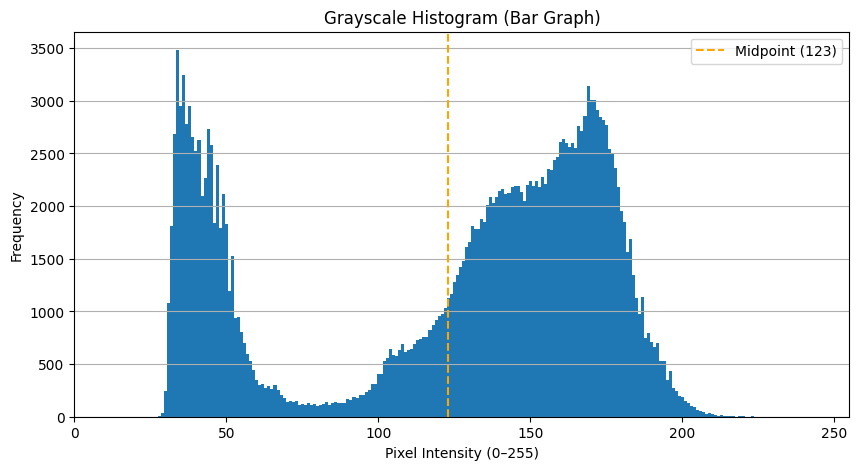

In [ ]:
midpoint = 123
showHistogramBar(img1, midpoint, threshold=None, 59, )
sosImg1 = binInvert(greyToBin(img1, midpoint))
sosImg1.save("output2.jpg")

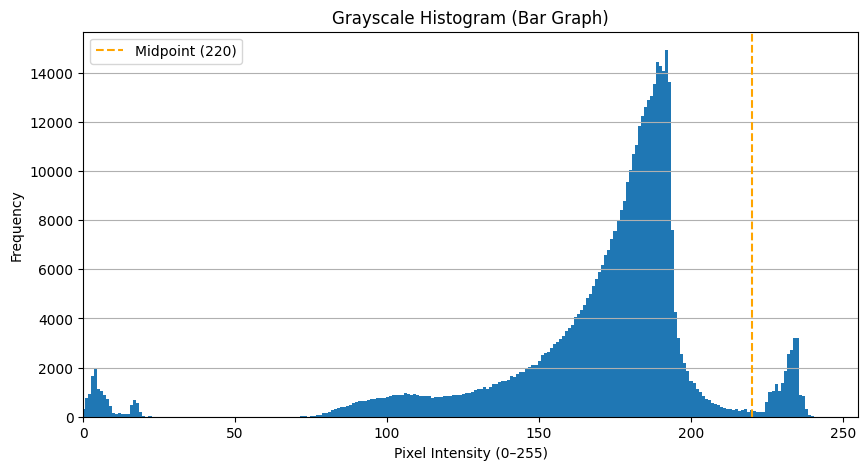

In [ ]:
#113.81387193475902 183.08616321949654
#148.45001757712777
midpoint = 220
showHistogramBar(img1, midpoint)
sosImg2 = greyToBin(img1, midpoint)
sosImg2.save("output3.jpg")

In [ ]:
sosImg4 = binAdd(sosImg1, sosImg2)

sosImg4.save("result.jpg")

In [ ]:
sosImg = greyToSauvolaBin(img1, 4)
sosImg.save("sauvola.jpg")

In [ ]:
sosImg5 = binErosion(binDilation(sosImg4, 7), 7)
sosImg5.save("experiment.jpg")

On Col 0/800
On Col 100/800
On Col 200/800
On Col 300/800
On Col 400/800
On Col 500/800
On Col 600/800
On Col 700/800
On Col 0/800
On Col 100/800
On Col 200/800
On Col 300/800
On Col 400/800
On Col 500/800
On Col 600/800
On Col 700/800


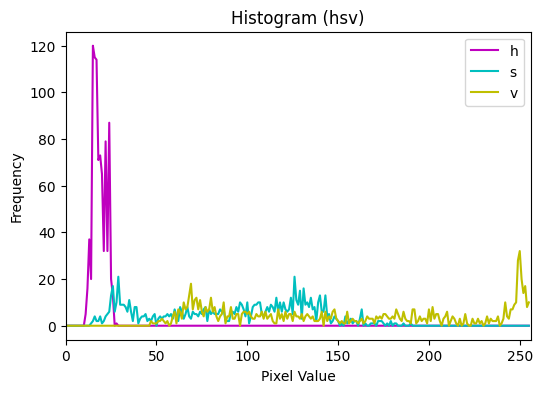

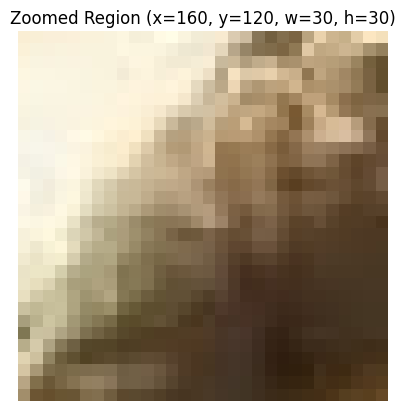

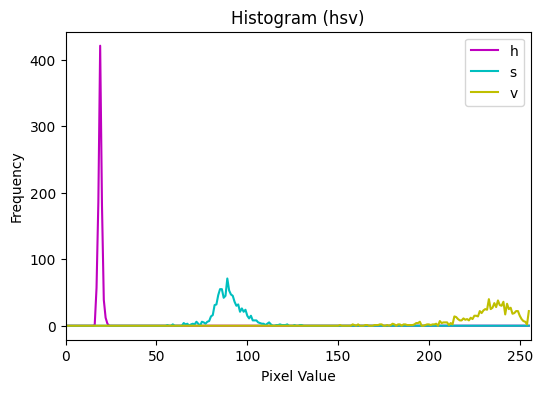

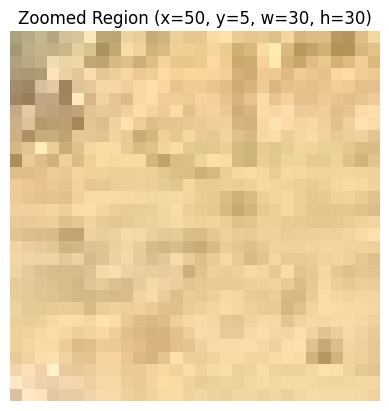

In [ ]:
img = cv2.imread("test6.jpg")

xstart = 160
wid = 30
ystart = 120
hei = 30
# Pick a sandy region
show_region_histogram(img, xstart, ystart, wid, hei, mode='hsv')

show_zoomed_region(img, xstart, ystart, wid, hei)

xstart2 = 50
wid2 = 30
ystart2 = 5
hei2 = 30
# Pick a rocky region
show_region_histogram(img, xstart2, ystart2, wid2, hei2, mode='hsv')
show_zoomed_region(img, xstart2, ystart2, wid2, hei2)

In [ ]:
def local_std(gray, ksize=9):
    gray = gray.astype(np.float32)

    mean = cv2.blur(gray, (ksize, ksize))
    mean_sq = cv2.blur(gray**2, (ksize, ksize))

    variance = mean_sq - mean**2
    std = np.sqrt(variance)
    return std

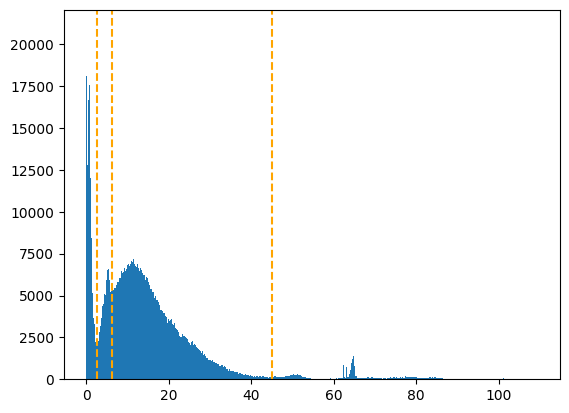

In [ ]:
std_v = local_std(cv2.imread("grayscaled.jpg"), 10)
plt.hist(std_v.ravel(), bins=1000)
plt.axvline(2.7, color='orange', linestyle='--', label=f"Midpoint ({3})")
plt.axvline(6.2, color='orange', linestyle='--', label=f"Midpoint ({3})")
plt.axvline(45, color='orange', linestyle='--', label=f"Midpoint ({3})")
#plt.xlim((0, 2000))
#plt.ylim((0, 10000))

In [ ]:
xstart = 160
wid = 30
ystart = 120
hei = 30

In [ ]:
sosImg10 = varianceMask(img1, 500, 10)

sosImg10.save("pls.jpg")

In [ ]:
sosImg = stdMask(img1, 45, 10)

sosImg.save("pls.jpg")

In [ ]:
def maskGreyImg(img, mask):
  width, height = img.size
  pixels = img.load()
  maskPixels = mask.load()

  newImg = Image.new(mode="L", size=(width, height))
  histogram = defaultdict(int)
  newPixels = newImg.load()
  for i in range(width1):
    for j in range(height1):
      histogram[pixels[i, j]] += 1

  mostFrequent = 0
  for i in range(1, 256):
    print("running")
    if (histogram[i] > histogram[mostFrequent]):
      mostFrequent = i

  for i in range(width):
    for j in range(height):
      if (maskPixels[i, j] == 0):
        newPixels[i, j] = mostFrequent
      else:
        newPixels[i, j] = pixels[i, j]

  return newImg

In [ ]:
sosImg11 = maskGreyImg(img1, sosImg10)

sosImg11.save("pls2.jpg")

running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running
running


In [ ]:
sosImg = basicGlobalThresholding(img1, 30)

sosImg.save("result.jpg")

30
22.745122557138124 91.82998022195363
57.28755138954588
26.826446644664465 97.96322050809732
62.39483357638089
28.169246248109747 98.80549343353711
63.487369840823426
28.495644391408113 98.99311790668348
63.74438114904579
28.495644391408113 98.99311790668348
63.74438114904579


In [ ]:
sosImg = adaptiveThresholding(img1, 25)

sosImg.save("result.jpg")

In [ ]:
sosImg = binDilation(binDilation(adaptiveVarianceThresholding(img1, 10, 4, 30),  10), 10)

sosImg = sosImg.filter(ImageFilter.MedianFilter(3))
sosImg.save("result.jpg")

On Col 0/800
On Col 100/800
On Col 200/800
On Col 300/800
On Col 400/800
On Col 500/800
On Col 600/800
On Col 700/800
On Col 0/800
On Col 100/800
On Col 200/800
On Col 300/800
On Col 400/800
On Col 500/800
On Col 600/800
On Col 700/800


In [ ]:
sosImg = niblackThresholding(img1, -0.2, 10)

sosImg.save("result.jpg")

In [ ]:
sosImg = bernsensThresholding(img1, 10)

sosImg.save("result.jpg")

In [ ]:
sosImg = globalVarianceThresholding(img1, 3)

sosImg.save("result.jpg")

In [ ]:
sosImg = adaptiveVarianceThresholding(img1, 5, 5, 100)

sosImg.save("result.jpg")